In [90]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point

import geopandas as gpd

# Aggregate all LineStrings into a single MultiLineString, then buffer the aggregate
from shapely.geometry import MultiLineString, Polygon

# Create a unary union of the LineStrings for a topologically-coherent merged geometry
from shapely.ops import unary_union
# Parameters for the normal distribution
mu = 0      # mean
sigma = 3# standard deviation

# Use separate random generators
rng1 = np.random.default_rng(seed=100)
rng2 = np.random.default_rng(seed=54)
n_samples = 10000

# Generate random data - 1000 samples from a uniform distribution using two different random generators
#y1 = rng1.uniform(low=mu - sigma, high=mu + sigma, size=n_samples)
#y2 = rng2.uniform(low=mu - sigma, high=mu + sigma, size=n_samples)
# p_true = 0.5  # 60% probability for True

# Generate random data - 1000 samples from a normal (Gaussian) distribution using two different random generators
y1 = rng1.normal(loc=mu, scale=sigma, size=n_samples)
y2 = rng2.normal(loc=mu, scale=sigma, size=n_samples)
p_true = 0.5  # 50% probability for True

# Generate a binomial distribution (0 = False, 1 = True)
binom_data = np.random.binomial(1, p_true, n_samples)

In [91]:

def angle_between_vectors(vec_a, rotated_vec=[1.0, 0.0]):
    # vec_a and rotated_vec expected to be [x, y]
    a = np.array(vec_a)
    b = np.array(rotated_vec)
    if np.linalg.norm(a) == 0 or np.linalg.norm(b) == 0:
        return 0.0
    # Calculate angle in radians
    dot = np.dot(a, b)
    det = a[0] * b[1] - a[1] * b[0]
    angle_rad = np.arctan2(det, dot)
    return np.degrees(angle_rad)

def safe_unit_vector(bottom_points, tol=1e-8):
    """
    Returns a unit vector for the line defined by bottom_points. 
    If invalid input or the two points are extremely close, returns None.
    They are not really coincident points—just extremely close numerically.
    """
    # Validate: must be a list of 2 coordinate tuples
    if (
        isinstance(bottom_points, list)
        and len(bottom_points) == 2
        and all(isinstance(pt, tuple) and len(pt) == 2 for pt in bottom_points)
    ):
        p1 = np.array(bottom_points[0], dtype=float)
        p2 = np.array(bottom_points[1], dtype=float)
        vec = p2 - p1
        norm = np.linalg.norm(vec)

        # Instead of coincident check, check that points are not "almost" coincident
        if norm <= tol or np.any(np.isnan(vec)):
            return None

        return (vec / norm).tolist()
    # If we get here, input was not valid, so return to previous logic: None
    # (i.e., do what the old safe_unit_vector used to do on fallback)
    return None

def get_bottom_two_points(geom,angle,rotattion = True):
    coords = list(geom.exterior.coords)
    # Remove duplicates and convert to Point objects
    coords = list(dict.fromkeys(coords))
    # Find the two points with the smallest y values (i.e., bottommost points)
    bottom_two = sorted(coords, key=lambda pt: pt[1])[:2]
    # Now sort these two points only by x ascending (left to right)
    bottom_two = sorted(bottom_two, key=lambda pt: pt[0])
    if rotattion:
        bottom_two = [rotate(Point(pt), angle=angle, origin=(0, 0)) for pt in bottom_two]
    else:
        bottom_two = [Point(pt) for pt in bottom_two]
    return [tuple(pt.coords[0]) for pt in bottom_two]

def get_central_line_vertical(row):
    bounds = row.minimum_rotated_rectangle.bounds
    min_x, min_y, max_x, max_y = bounds
    central_x = (min_x + max_x) / 2
    central_y = (min_y + max_y) / 2
    return LineString([(central_x, min_y), (central_x, max_y)])

In [92]:
# Iterate this process and store the intersection_lengths for each iteration, sampling without repetition

# Number of iterations and samples per iteration
n_iterations = 2000
samples_per_iter = 3
all_intersection_lengths = []
all_angle_measured = []
spread = []
std_devs = []
# Maintain a pool of indices for sampling without repetition across all iterations
available_indices = np.arange(len(y1))

# Shuffle indices for randomness
np.random.shuffle(available_indices)

# Adjust total samples if not enough for each full iteration
max_possible_iters = len(y1) // samples_per_iter
actual_iters = min(n_iterations, max_possible_iters)

# If needed, also prepare binom_data for later use in each iteration:
binom_data_iter = binom_data[available_indices[:actual_iters * samples_per_iter]].reshape(actual_iters, samples_per_iter)

for it in range(actual_iters):
    # Get indices for this iteration (without replacement)
    sample_start = it * samples_per_iter
    sample_end = sample_start + samples_per_iter
    idx = available_indices[sample_start:sample_end]

    y1_samples = y1[idx]
    y2_samples = y2[idx]

    # Create lines and rotate each by 10 degrees counterclockwise around the origin
    from shapely import affinity
    lines = [
        affinity.rotate(LineString([(-10, y1_samples[i]), (10, y2_samples[i])]), 0,origin=(0, 0))
        for i in range(samples_per_iter)
    ]

    unioned_lines = unary_union(lines)

    # Buffer the unioned geometry
    buffered = unioned_lines.buffer(5, cap_style=2)

    # Create a vertical line from (-10, 10) to (10, 10)
    # Create a polygon (rectangle) centered at x=0, y from -10 to 10, width in x of 0.5
    vertical_box_coords = [(-0.25, -10), (0.25, -10), (0.25, 10), (-0.25, 10), (-0.25, -10)]
    vertical_box_poly = Polygon(vertical_box_coords)

    # Intersect the vertical line with the buffer
    inter_road = buffered.intersection(vertical_box_poly)
    inter_bc = unioned_lines.intersection(vertical_box_poly)
    bottom_points = get_bottom_two_points(inter_road, 0, rotattion = False)
    unit_vector = safe_unit_vector(bottom_points)
    angle_measured = angle_between_vectors(unit_vector,rotated_vec=[1,0])
    central_line = get_central_line_vertical(inter_road)

    all_intersection_lengths.append({"iteration": it, "length": central_line.length})
    all_angle_measured.append({"iteration": it, "angle": angle_measured})
    spread.append({"iteration": it, "spread": inter_bc.bounds[3] - inter_bc.bounds[1]})


In [93]:
import pandas as pd

# Assuming all_intersection_lengths and spread are lists of dicts with 'iteration' and 'length'/'spread'
# Create a DataFrame from both lists
df = pd.DataFrame({
    'intersection_length': [item['length'] for item in all_intersection_lengths],
    'angle_measured': [item['angle'] for item in all_angle_measured],
    'spread': [item['spread'] for item in spread]
})
df['diff'] = (df['intersection_length'] - df['spread'])/10

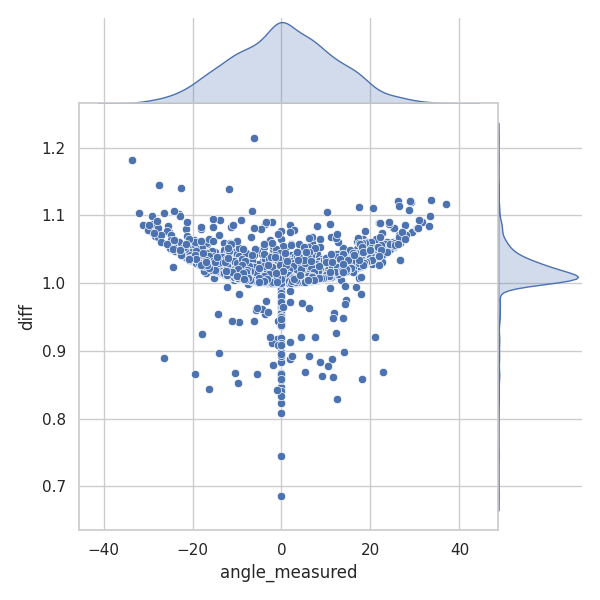

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the grid of plots, with main scatter plot and marginal distributions
sns.set(style="whitegrid")
g = sns.JointGrid(data=df, x='angle_measured', y='diff', space=0)
g.plot_joint(sns.scatterplot)
g.plot_marginals(sns.kdeplot, fill=True)

plt.show()